# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [23]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Isnpeksi data
df.info()
# Menampilkan data yang hilang
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [24]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Mengganti missing value dengan modus data
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Checking data yang hilang
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [26]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Inspeksi value ke semua kolom
at_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

# Mengganti data jadi others
cols_with_question_mark = ['workclass', 'occupation', 'native-country']
for col in cols_with_question_mark:
    df[col] = df[col].replace('?', 'Others')

# Merapikan kolom workclass
df['workclass'] = df['workclass'].replace({
    'Without-pay': 'Others',
    'Never-worked': 'Others'
})

# Merapikan kolom native country mengganti country selain US jadi others
df['native-country'] = df['native-country'].apply(lambda x: x if x == 'United-States' else 'Others')

# Menhilangkan titik dari income agar jadi 1 dengan yang tanpa titik
df['income'] = df['income'].str.replace('.', '', regex=False)

# menampilkan data ulang
for col in ['workclass', 'occupation', 'native-country', 'income']:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print("\n")

=== workclass ===
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


=== occupation ===


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

In [27]:
# Import lib
import matplotlib.pyplot as plt
import seaborn as sns

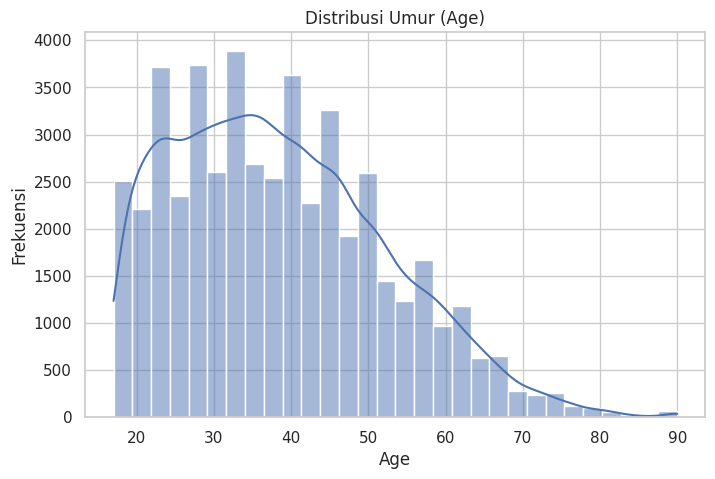

In [28]:
# Set tema
sns.set_theme(style="whitegrid")
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', kde=True, bins=30)
plt.title('Distribusi Umur (Age)')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

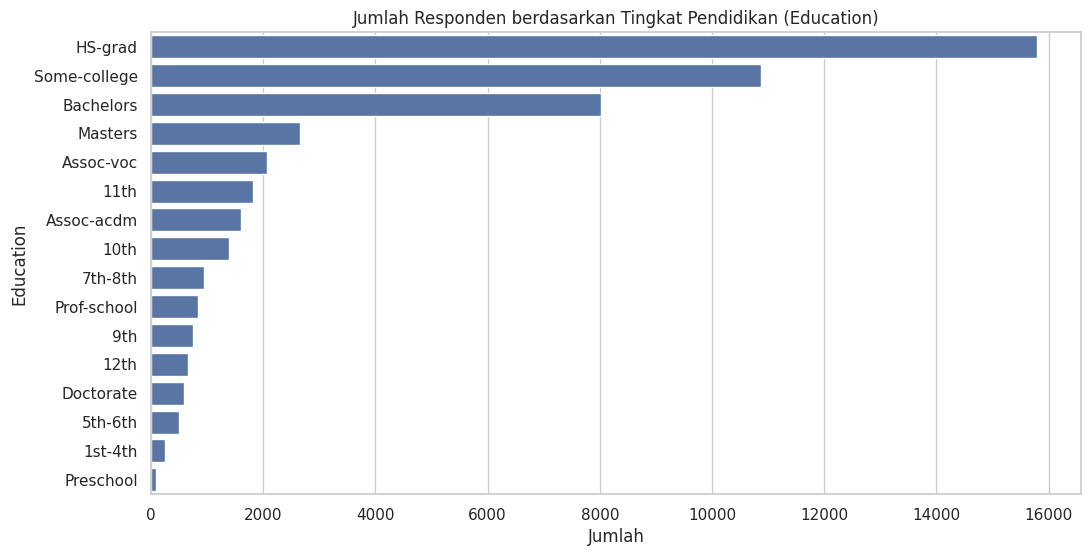

In [30]:
# Set tema
sns.set_theme(style="whitegrid")
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='education', order=df['education'].value_counts().index)
plt.title('Jumlah Responden berdasarkan Tingkat Pendidikan (Education)')
plt.xlabel('Jumlah')
plt.ylabel('Education')
plt.show()

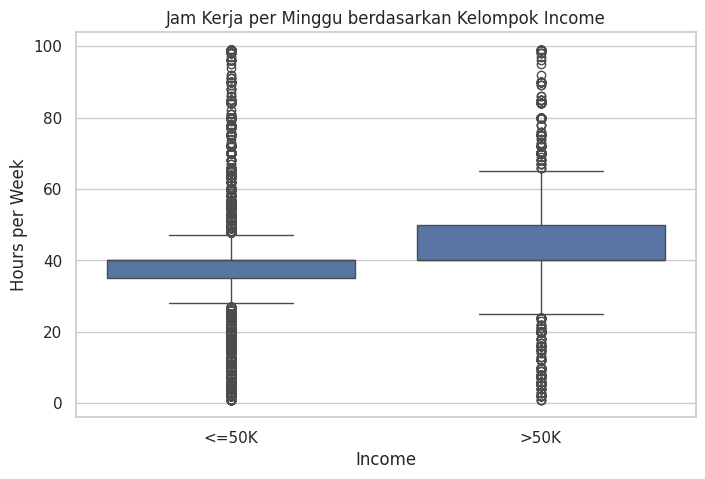

In [32]:
# Set tema
sns.set_theme(style="whitegrid")
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Jam Kerja per Minggu berdasarkan Kelompok Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

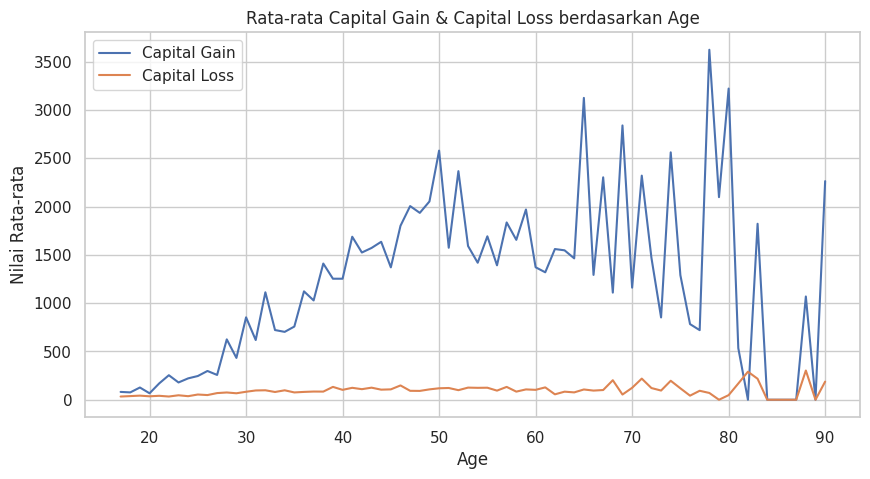

In [29]:
# Set tema
sns.set_theme(style="whitegrid")
# Rata rata nilai gain dan loss based on umur
age_grouped = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()
# Jawab 1.4 - Lineplot
plt.figure(figsize=(10, 5))
sns.lineplot(data=age_grouped, x='age', y='capital-gain', label='Capital Gain')
sns.lineplot(data=age_grouped, x='age', y='capital-loss', label='Capital Loss')
plt.title('Rata-rata Capital Gain & Capital Loss berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Nilai Rata-rata')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
# Jawab dengan komentar python

# 1. Distribusi data age menampilkan bahwa age itu right skewed dimana di tampilkan di situ data age kebanyakan di umur 20-50 dan terus menurun hingga lansia
# 2. Imputasi data menggunakan median dikarenakan distribusi miring ke kanan maka nilai median jadi lebih tahan terhadap outlier,
# dan tidak terpengaruh nilai extrem jika di banding dengan mean
# 3. Kategori '<=50K': Memiliki jumlah outlier yang SANGAT BANYAK (dominan berada di bawah/di atas jam kerja standar 40 jam/minggu),
# sedangkan Kategori '>50K': Memiliki jumlah outlier yang LEBIH SEDIKIT dibandingkan kelompok <=50K. Kategori paling banyak memiliki outlier: Kelompok '<=50K'.

'\n  Bisa dengan multiple comment\n  seperti ini\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [33]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Encoding var sex
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
# Encoding var income
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})
# cek hasil encoding
print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.230369       0.332613        0.227687      0.223013   

                capital-loss    income  
age                 0.056944  0.230369  
education-num       0.080972  0.332613  
hours-per-week      0.054467  0.227687  
capital-gain       -0.031441  0.223013  
capital-loss        1.000000  0.147554  
income              0.147554  1.000000  


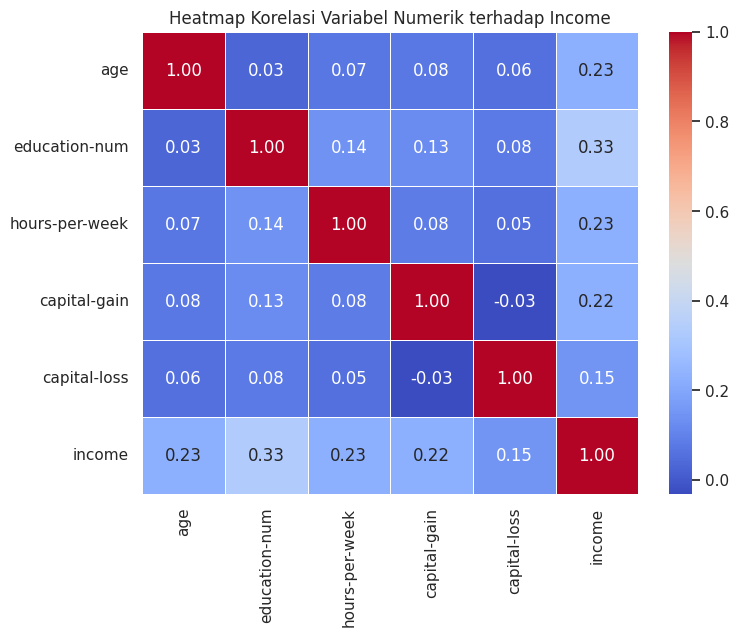

In [37]:
# Import lib
import matplotlib.pyplot as plt
import seaborn as sns

# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Analisis korelasi
cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
corr_matrix = df[cols].corr()
# Menampilkan hasil korelasi
print(corr_matrix)
# Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik terhadap Income')
plt.show()

In [17]:
from IPython.core.debugger import make_arrow
# Hasil analisis jelaskan pada cell ini

# Korelasi terkuat terhadap income adalah education-num dengan korelasi positif tertinggi terhadap income yang menunjukan bahwa semakin tinggi pendidikan make
# semakin tinggi juga kesempatan orang untuk mendapatkan pekerjan yang incomenya >50K. Umur dan jam kerja juga menunjukan korelasi positif terhadap income dimana
# Usia yang lebih tua dan jam kerja yang lama berpengaruh terhadap income

# Korelasi lemah : capital-gain dan capital-loss memiliki korelasi positif yang relatif lebih kecil terhadap income karena sebagian besar populasi data bernilai 0 pada fitur ini

# Korelasi antar variabel bebas : seluruh variabel bebas memiliki nilai korelasi antar-sesama yang tergolong rendah
# Hal ini mengindikasikan bahwa tidak terjadi masalah Multikolinearitas antar-fitur.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [38]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(_, _), (X_test, y_test) = mnist.load_data()

# Pre processing data
def preprocess_mnist_test(X, y):
    # a. Normalisasi piksel dari rentang [0, 255] ke [0, 1]
    X_normalized = X.astype('float32') / 255.0

    # b. Flattening image dari 2D (28x28) menjadi 1D (784 features)
    X_flattened = X_normalized.reshape(X_normalized.shape[0], -1)

    return X_flattened, y

# Menjalankan fungsi dari data test
X_test_prep, y_test_prep = preprocess_mnist_test(X_test, y_test)

# Cek hasil preprocessing
print("Ukuran X_test awal    :", X_test.shape)        # (10000, 28, 28)
print("Ukuran X_test olahan  :", X_test_prep.shape)   # (10000, 784)
print("Rentang Nilai Piksel  :", X_test_prep.min(), "-", X_test_prep.max())

Ukuran X_test awal    : (10000, 28, 28)
Ukuran X_test olahan  : (10000, 784)
Rentang Nilai Piksel  : 0.0 - 1.0


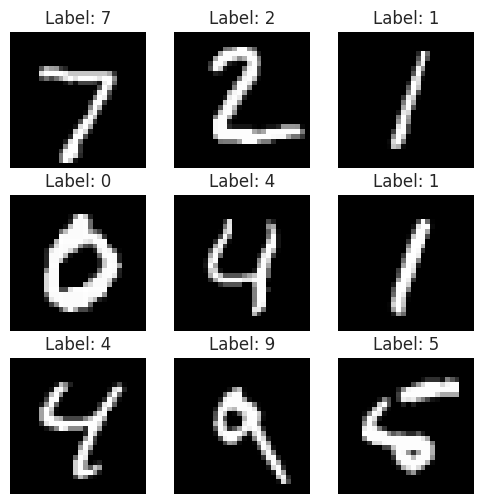

In [39]:
# Inspeksi Visual
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Dimensi setelah upsampling: (10000, 32, 32)


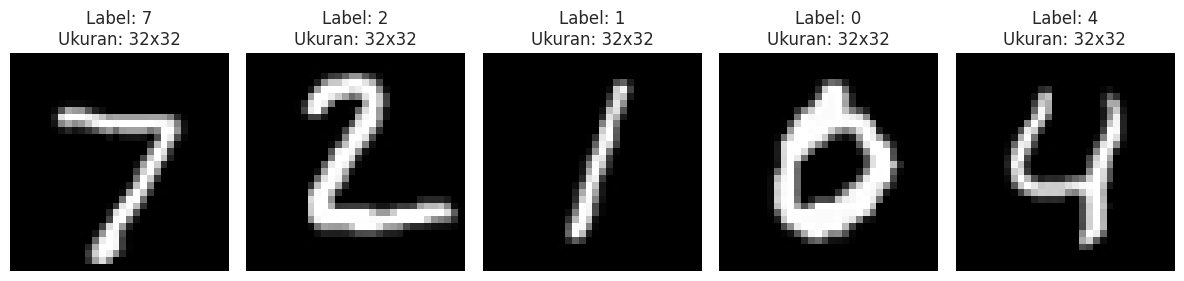

In [40]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Import lib
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create empty array
X_test_resized = np.zeros((X_test.shape[0], 32, 32), dtype=X_test.dtype)

# Ubah ukuran citra
for i in range(X_test.shape[0]):
    X_test_resized[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)

print("Dimensi setelah upsampling:", X_test_resized.shape)

# Menampilkan hasil upsampling
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_resized[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}\nUkuran: 32x32")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [41]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Normalisasi piksel dengan rentang 0-1
X_test_normalized = X_test_resized.astype('float32') / 255.0
# Cek nilai min max
print("Nilai Min Piksel :", X_test_normalized.min())
print("Nilai Max Piksel :", X_test_normalized.max())
print("Tipe Data        :", X_test_normalized.dtype)

Nilai Min Piksel : 0.0
Nilai Max Piksel : 1.0
Tipe Data        : float32


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [42]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Import lib
import numpy as np

# Buat array kosong
X_test_flatten = np.zeros((X_test_normalized.shape[0], 32 * 32), dtype='float32')

# Mengubah matrix jadi array 1 Dim
for i in range(X_test_normalized.shape[0]):
    X_test_flatten[i] = X_test_normalized[i].flatten()

# Cek dimensi
print("Dimensi sebelum flattening :", X_test_normalized.shape)
print("Dimensi setelah flattening :", X_test_flatten.shape)

Dimensi sebelum flattening : (10000, 32, 32)
Dimensi setelah flattening : (10000, 1024)
